<a href="https://www.kaggle.com/code/robiulhasanjisan/disease-prediction-ml?scriptVersionId=310667710" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/healthcare-disease-prediction-dataset/healthcare_disease_prediction_dataset.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, RobustScaler, PowerTransformer
)

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, matthews_corrcoef
)

from sklearn.multioutput import MultiOutputClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

#  DATA LOADING AND INITIAL INSPECTION

In [3]:

df = pd.read_csv('/kaggle/input/datasets/algozee/healthcare-disease-prediction-dataset/healthcare_disease_prediction_dataset.csv')


In [4]:
print(f"Shape: {df.shape}")

Shape: (1000, 20)


In [5]:
from IPython.display import display

display(df.head())

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [6]:
display(df.dtypes)

Age                      int64
Gender                  object
Blood Pressure          object
Cholesterol             object
Glucose                 object
Smoking                 object
Alcohol Consumption     object
Exercise                object
BMI                    float64
Family History          object
Heart Disease            int64
Diabetes                 int64
Stroke                   int64
Kidney Disease           int64
Cancer                   int64
Alzheimer's Disease      int64
COPD                     int64
Liver Disease            int64
Parkinson's Disease      int64
Tuberculosis             int64
dtype: object

In [7]:
print(f"\nMissing Values:\n{df.isnull().sum()}")


Missing Values:
Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64


In [8]:


# Define disease columns
disease_cols = [
    'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease',
    'Cancer', "Alzheimer's Disease", 'COPD', 'Liver Disease',
    "Parkinson's Disease", 'Tuberculosis'
]

# Define feature columns (excluding disease columns)
feature_cols = [col for col in df.columns if col not in disease_cols]

print(f"\nFeatures: {feature_cols}")
print(f"Target Diseases: {disease_cols}")


Features: ['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol Consumption', 'Exercise', 'BMI', 'Family History']
Target Diseases: ['Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer', "Alzheimer's Disease", 'COPD', 'Liver Disease', "Parkinson's Disease", 'Tuberculosis']


## DEFINE FEATURE GROUPS

In [9]:
feature_cols = [
    'Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose',
    'Smoking', 'Alcohol Consumption', 'Exercise', 'BMI', 'Family History'
]

disease_cols = [
    'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
    "Alzheimer's Disease", 'COPD', 'Liver Disease',
    "Parkinson's Disease", 'Tuberculosis'
]

risk_factors = ['Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']

## ENCODE YES/NO

In [10]:
df[risk_factors] = df[risk_factors].replace({'Yes': 1, 'No': 0})

#  EDA

## DISEASE PREVALENCE

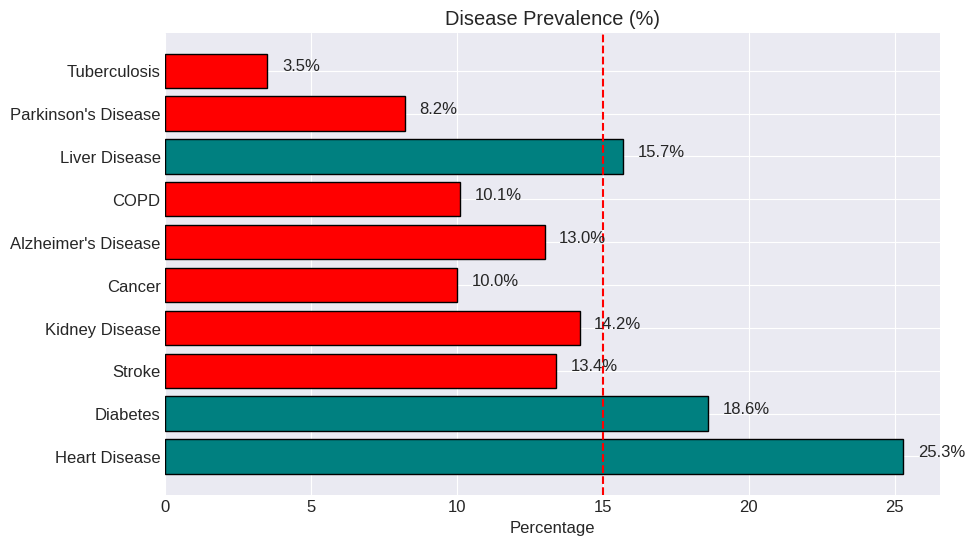

In [11]:
prevalence = df[disease_cols].mean() * 100

plt.figure(figsize=(10,6))
colors = ['red' if p < 15 else 'teal' for p in prevalence]

plt.barh(disease_cols, prevalence, color=colors, edgecolor='black')
plt.title("Disease Prevalence (%)")
plt.xlabel("Percentage")

for i, v in enumerate(prevalence):
    plt.text(v + 0.5, i, f"{v:.1f}%")

plt.axvline(15, linestyle='--', color='red')
plt.show()

## AGE DISTRIBUTION

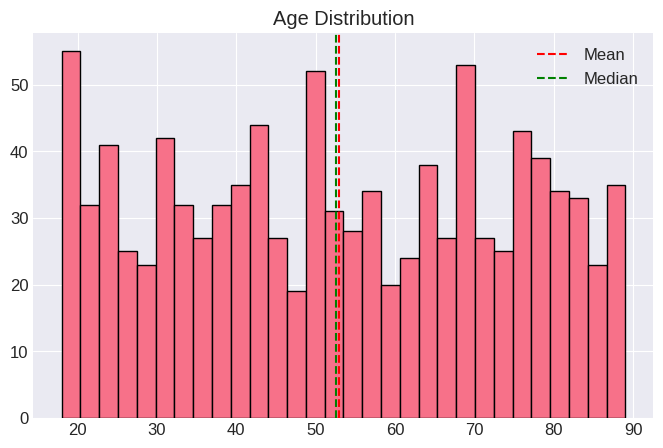

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30, edgecolor='black')

plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label='Median')

plt.title("Age Distribution")
plt.legend()
plt.show()

## GENDER DISTRIBUTION

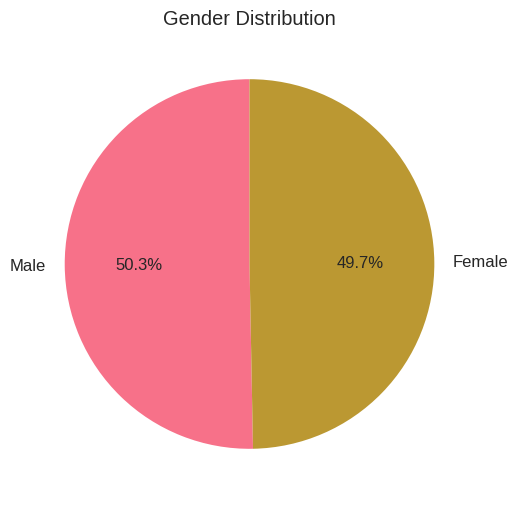

In [13]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## DISEASE BURDEN

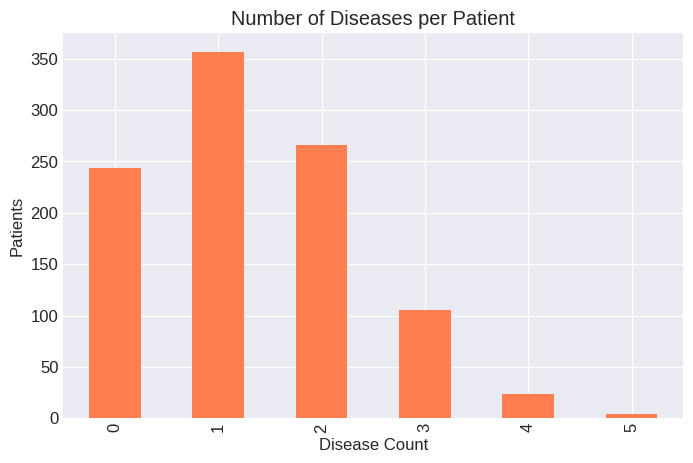

In [14]:
disease_count = df[disease_cols].sum(axis=1)

plt.figure(figsize=(8,5))
disease_count.value_counts().sort_index().plot(kind='bar', color='coral')

plt.title("Number of Diseases per Patient")
plt.xlabel("Disease Count")
plt.ylabel("Patients")
plt.show()

## AGE vs DISEASE

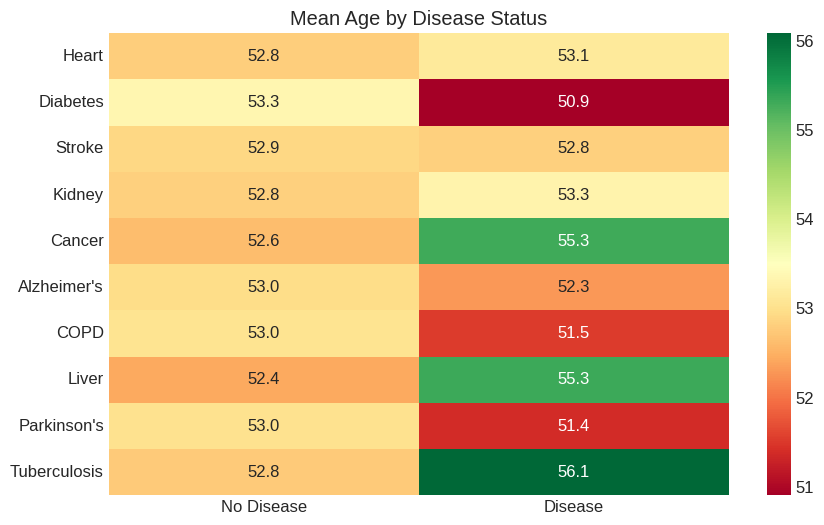

In [15]:
age_matrix = []

for d in disease_cols:
    age_matrix.append([
        df.loc[df[d] == 0, 'Age'].mean(),
        df.loc[df[d] == 1, 'Age'].mean()
    ])

plt.figure(figsize=(10,6))
sns.heatmap(
    age_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    xticklabels=["No Disease", "Disease"],
    yticklabels=[d.replace(" Disease", "") for d in disease_cols]
)

plt.title("Mean Age by Disease Status")
plt.show()

## BMI DISTRIBUTION

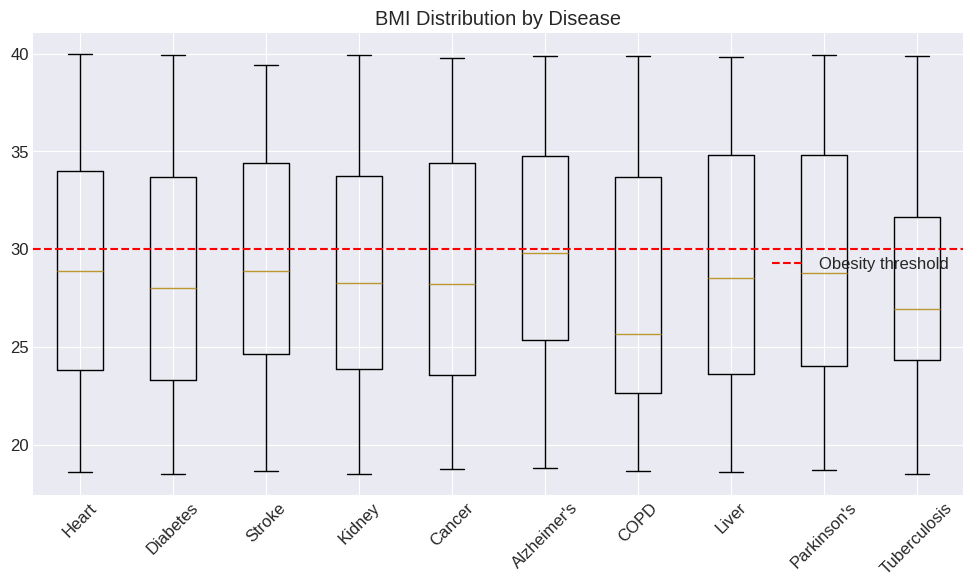

In [16]:
bmi_data = []
labels = []

for d in disease_cols:
    values = df.loc[df[d] == 1, 'BMI'].dropna()

    if len(values) > 5:
        bmi_data.append(values)
        labels.append(d.replace(" Disease", ""))

plt.figure(figsize=(12,6))

plt.boxplot(bmi_data, labels=labels)

plt.axhline(30, color='red', linestyle='--', label='Obesity threshold')
plt.xticks(rotation=45)

plt.title("BMI Distribution by Disease")
plt.legend()
plt.show()

## DISEASE CO-OCCURRENCE

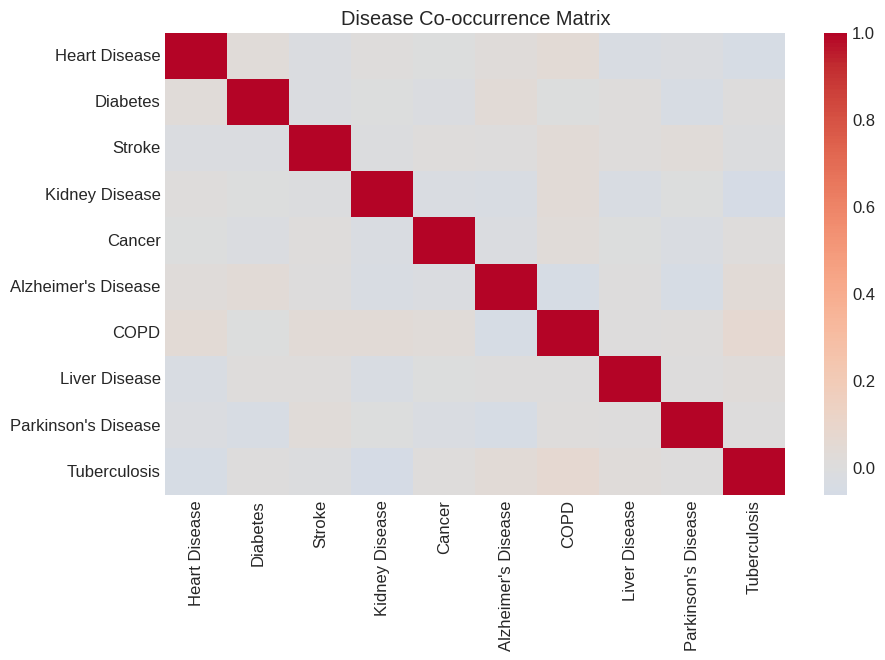

In [17]:
plt.figure(figsize=(10,6))

corr = df[disease_cols].corr()

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Disease Co-occurrence Matrix")
plt.show()

## RISK FACTORS BY DISEASE

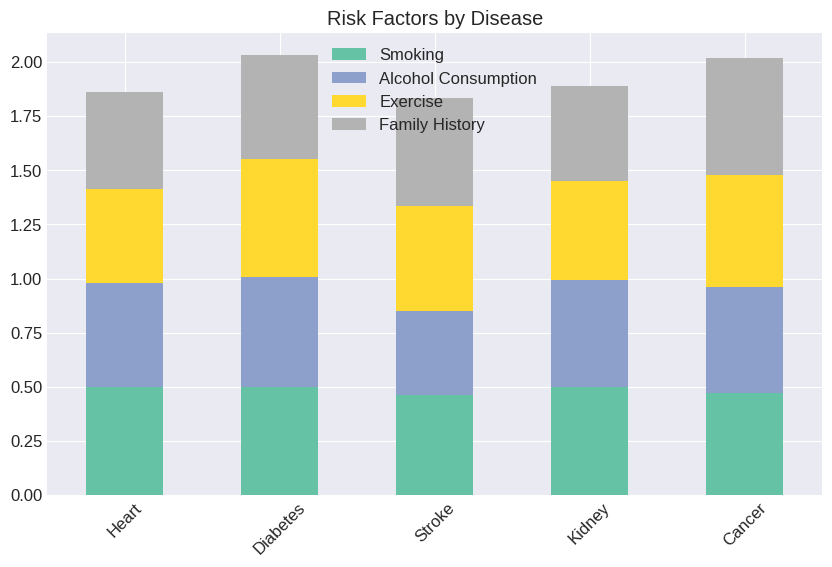

In [18]:
risk_data = []

for d in disease_cols[:5]:
    risk_data.append(df.loc[df[d] == 1, risk_factors].mean())

risk_df = pd.DataFrame(
    risk_data,
    index=[d.replace(" Disease", "") for d in disease_cols[:5]]
)

risk_df.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')

plt.title("Risk Factors by Disease")
plt.xticks(rotation=45)
plt.show()

## AGE vs BMI SCATTER

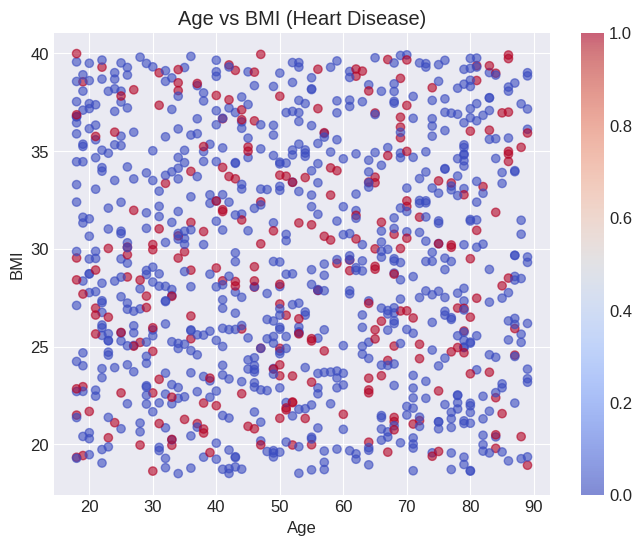

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Age'],
    df['BMI'],
    c=df['Heart Disease'],
    cmap='coolwarm',
    alpha=0.6
)

plt.title("Age vs BMI (Heart Disease)")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.colorbar()
plt.show()

In [20]:
print("AGE SUMMARY")
print(df['Age'].describe())



AGE SUMMARY
count    1000.000000
mean       52.881000
std        20.958915
min        18.000000
25%        34.750000
50%        52.500000
75%        71.000000
max        89.000000
Name: Age, dtype: float64


In [21]:
print("\nBMI SUMMARY")
print(df['BMI'].describe())



BMI SUMMARY
count    1000.000000
mean       29.213037
std         6.196368
min        18.504881
25%        23.924004
50%        28.892349
75%        34.663806
max        39.974048
Name: BMI, dtype: float64


In [22]:

print("\nDisease Prevalence:")
print(prevalence.sort_values(ascending=False))


Disease Prevalence:
Heart Disease          25.3
Diabetes               18.6
Liver Disease          15.7
Kidney Disease         14.2
Stroke                 13.4
Alzheimer's Disease    13.0
COPD                   10.1
Cancer                 10.0
Parkinson's Disease     8.2
Tuberculosis            3.5
dtype: float64


# DATA PREPROCESSING 

In [23]:

df_encoded = df.copy()

# Handle Blood Pressure (ordinal)
bp_map = {'Low': 0, 'Normal': 1, 'High': 2}
df_encoded['Blood Pressure'] = df_encoded['Blood Pressure'].map(bp_map)

# Encode categorical variables
categorical_cols = ['Gender', 'Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Handle Glucose and Cholesterol
glucose_map = {'Normal': 0, 'High': 1}
chol_map = {'Normal': 0, 'High': 1}
df_encoded['Glucose'] = df_encoded['Glucose'].map(glucose_map)
df_encoded['Cholesterol'] = df_encoded['Cholesterol'].map(chol_map)

print(f"\nEncoded Glucose: {glucose_map}")
print(f"Encoded Cholesterol: {chol_map}")



Encoded Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded Smoking: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Encoded Alcohol Consumption: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Encoded Exercise: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Encoded Family History: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Encoded Glucose: {'Normal': 0, 'High': 1}
Encoded Cholesterol: {'Normal': 0, 'High': 1}



#   FEATURE ENGINEERING

In [24]:



def create_advanced_features(df):
    df = df.copy()
    
    # Interaction features
    df['BMI_Age'] = df['BMI'] * df['Age']
    df['BMI_BP'] = df['BMI'] * df['Blood Pressure']
    df['Age_BP'] = df['Age'] * df['Blood Pressure']
    df['Glucose_Chol'] = df['Glucose'] * df['Cholesterol']
    
    # Risk scores
    df['Metabolic_Risk'] = (df['BMI'] * df['Glucose'] * df['Cholesterol']) / 100
    df['Cardiovascular_Risk'] = (df['Blood Pressure'] + df['Cholesterol'] + df['Smoking']) / 3
    df['Lifestyle_Risk'] = (df['Smoking'] + df['Alcohol Consumption'] + (1 - df['Exercise'])) / 3
    df['Genetic_Risk'] = df['Family History'] * (1 + df['Age'] / 100)
    
    # Polynomial features
    df['Age_Squared'] = df['Age'] ** 2
    df['BMI_Squared'] = df['BMI'] ** 2
    
    # Composite scores
    df['Total_Risk'] = (df['Metabolic_Risk'] + df['Cardiovascular_Risk'] + 
                        df['Lifestyle_Risk'] + df['Genetic_Risk'])
    
    df['Metabolic_Syndrome'] = ((df['BMI'] > 30) & (df['Glucose'] == 1) & 
                                 (df['Cholesterol'] == 1)).astype(int)
    
    return df

df_encoded = create_advanced_features(df_encoded)
print(f"Original features: {len(feature_cols)}")
print(f"New features added: 9")
print(f"Total features: {len(df_encoded.columns)}")

# Define final feature list
final_features = [
    'Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose',
    'Smoking', 'Alcohol Consumption', 'Exercise', 'BMI', 'Family History',
    'BMI_Age', 'BMI_BP', 'Age_BP', 'Glucose_Chol',
    'Metabolic_Risk', 'Cardiovascular_Risk', 'Lifestyle_Risk', 'Genetic_Risk',
    'Age_Squared', 'BMI_Squared', 'Total_Risk', 'Metabolic_Syndrome'
]

X = df_encoded[final_features]
y = df_encoded[disease_cols]

print(f"\nFinal feature matrix shape: {X.shape}")


Original features: 10
New features added: 9
Total features: 32

Final feature matrix shape: (1000, 22)


#  DATA TRANSFORMATION

In [25]:

# Use RobustScaler for outlier resistance
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Apply PowerTransformer to normalize skewed distributions
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X_scaled)

print(f"Applied RobustScaler + PowerTransformer")
print(f"Transformed data shape: {X_transformed.shape}")

Applied RobustScaler + PowerTransformer
Transformed data shape: (1000, 22)


#  TRAIN-TEST SPLIT WITH SAFE STRATIFICATION

In [26]:


# SAFE stratification (multi-label robust version)
y_strat = y.astype(str).agg('_'.join, axis=1)

# remove rare classes (IMPORTANT FIX)
vc = y_strat.value_counts()
valid_classes = vc[vc >= 2].index
mask = y_strat.isin(valid_classes)

X_filtered = X_transformed[mask]
y_filtered = y[mask]
y_strat_filtered = y_strat[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_strat_filtered
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (747, 22)
Test set: (187, 22)


#  MODEL EVALUATION WITH DETAILED METRICS

In [27]:
class AdvancedMultiLabelModel:
    def __init__(self):
        self.models = {}
        self.thresholds = {}

    def fit(self, X, y):
        for disease in disease_cols:
            print(f"\nTraining model for {disease}...", end=' ')

           
            # imbalance handling
           
            pos_count = y[disease].sum()
            neg_count = len(y) - pos_count

            scale_weight = neg_count / max(pos_count, 1)
            scale_weight = min(scale_weight, 15)

            print(f"(pos={pos_count}, scale={scale_weight:.2f})", end=' ')

            
            # XGBoost model
        
            model = XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.03,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_weight,
                eval_metric='logloss',
                random_state=42,
                verbosity=0,
                n_jobs=-1
            )

            # Train directly (NO SMOTE)
            model.fit(X, y[disease])

            self.models[disease] = model

            # FIXED threshold (stable baseline)
            self.thresholds[disease] = 0.5

            print("Done")

        return self

    def predict(self, X):
        preds = np.zeros((X.shape[0], len(disease_cols)))

        for i, disease in enumerate(disease_cols):
            proba = self.models[disease].predict_proba(X)[:, 1]

            # safe clipping (prevents extreme probabilities)
            proba = np.clip(proba, 0.01, 0.99)

            preds[:, i] = (proba >= self.thresholds[disease]).astype(int)

        return preds

    def predict_proba(self, X):
        probas = np.zeros((X.shape[0], len(disease_cols)))

        for i, disease in enumerate(disease_cols):
            probas[:, i] = self.models[disease].predict_proba(X)[:, 1]

        return probas



print("\n Starting training...")
model = AdvancedMultiLabelModel()
model.fit(X_train, y_train)



y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)



results = {}

for i, disease in enumerate(disease_cols):

    f1 = f1_score(y_test[disease], y_pred[:, i], zero_division=0)
    precision = precision_score(y_test[disease], y_pred[:, i], zero_division=0)
    recall = recall_score(y_test[disease], y_pred[:, i], zero_division=0)

    try:
        auc = roc_auc_score(y_test[disease], y_proba[:, i])
    except:
        auc = 0

    try:
        ap = average_precision_score(y_test[disease], y_proba[:, i])
    except:
        ap = 0

    mcc = matthews_corrcoef(y_test[disease], y_pred[:, i])

    tn, fp, fn, tp = confusion_matrix(
        y_test[disease], y_pred[:, i], labels=[0, 1]
    ).ravel()

    results[disease] = {
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "AUC": auc,
        "AP": ap,
        "MCC": mcc,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }


macro_f1 = np.mean([results[d]["F1"] for d in disease_cols])
micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n OVERALL PERFORMANCE")

print(f"Macro F1:     {macro_f1:.4f}")
print(f"Micro F1:     {micro_f1:.4f}")
print(f"Weighted F1:  {weighted_f1:.4f}")



print("\n PER-DISEASE PERFORMANCE")


print(f"{'Disease':<25}{'F1':<7}{'Prec':<7}{'Rec':<7}{'AUC':<7}{'MCC':<7}")

for disease in disease_cols:
    print(
        f"{disease:<25}"
        f"{results[disease]['F1']:<7.3f}"
        f"{results[disease]['Precision']:<7.3f}"
        f"{results[disease]['Recall']:<7.3f}"
        f"{results[disease]['AUC']:<7.3f}"
        f"{results[disease]['MCC']:<7.3f}"
    )


 Starting training...

Training model for Heart Disease... (pos=181, scale=3.13) Done

Training model for Diabetes... (pos=124, scale=5.02) Done

Training model for Stroke... (pos=90, scale=7.30) Done

Training model for Kidney Disease... (pos=102, scale=6.32) Done

Training model for Cancer... (pos=61, scale=11.25) Done

Training model for Alzheimer's Disease... (pos=88, scale=7.49) Done

Training model for COPD... (pos=64, scale=10.67) Done

Training model for Liver Disease... (pos=104, scale=6.18) Done

Training model for Parkinson's Disease... (pos=51, scale=13.65) Done

Training model for Tuberculosis... (pos=19, scale=15.00) Done

 OVERALL PERFORMANCE
Macro F1:     0.0844
Micro F1:     0.1214
Weighted F1:  0.1181

 PER-DISEASE PERFORMANCE
Disease                  F1     Prec   Rec    AUC    MCC    
Heart Disease            0.253  0.278  0.233  0.580  0.056  
Diabetes                 0.129  0.133  0.125  0.505  -0.044 
Stroke                   0.133  0.130  0.136  0.495  0.015  


# Performance

## Performance Heatmap (Standalone)

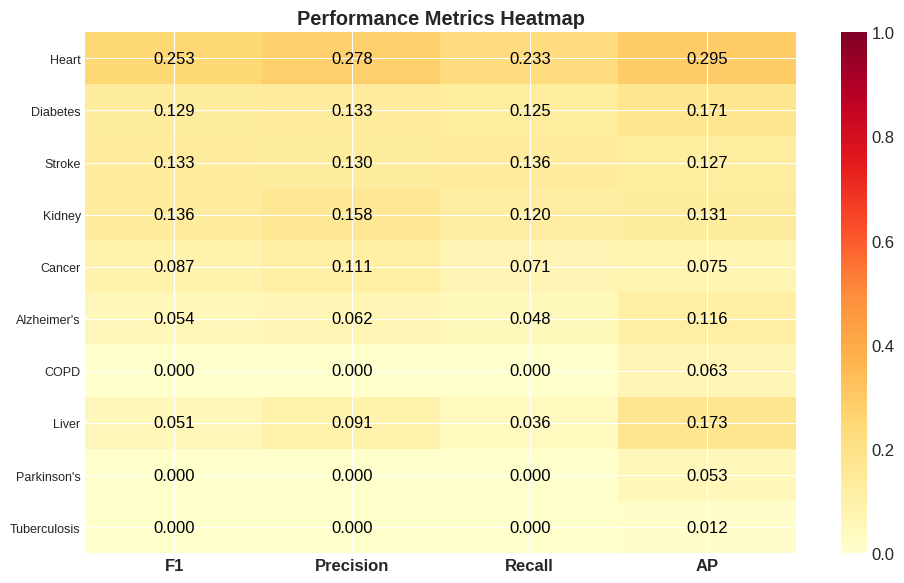

In [28]:
metrics_matrix = []

for disease in disease_cols:
    metrics_matrix.append([
        results[disease]['F1'],
        results[disease]['Precision'],
        results[disease]['Recall'],
        results[disease]['AP']
    ])

plt.figure(figsize=(10, 6))

im = plt.imshow(metrics_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

plt.xticks(
    range(4),
    ['F1', 'Precision', 'Recall', 'AP'],
    fontweight='bold'
)

plt.yticks(
    range(len(disease_cols)),
    [d.replace(' Disease', '') for d in disease_cols],
    fontsize=9
)

plt.title('Performance Metrics Heatmap', fontweight='bold')

for i in range(len(disease_cols)):
    for j in range(4):
        value = metrics_matrix[i][j]
        plt.text(
            j, i, f'{value:.3f}',
            ha='center', va='center',
            color='white' if value > 0.5 else 'black'
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

## F1 vs PREVALENCE

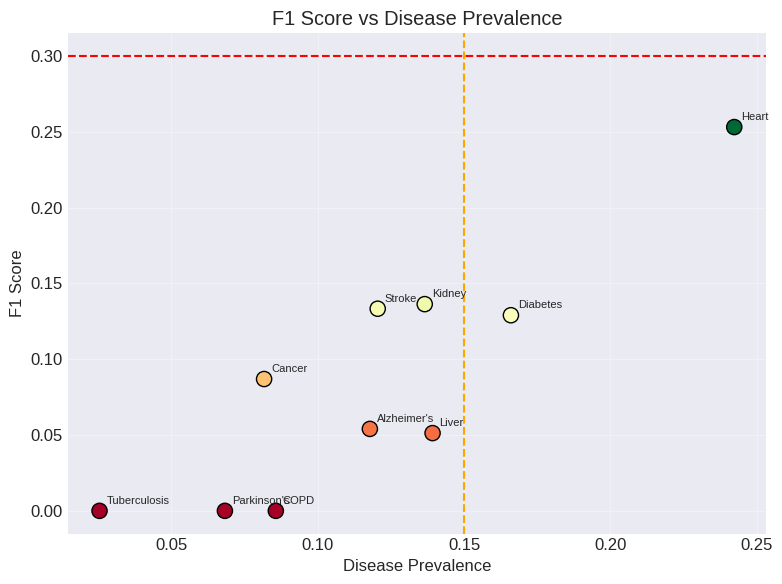

In [29]:


prevalences = [y_train[d].mean() for d in disease_cols]
f1_scores = [results[d]['F1'] for d in disease_cols]

plt.figure(figsize=(8, 6))
plt.scatter(prevalences, f1_scores, s=120, c=f1_scores, cmap='RdYlGn',
            edgecolors='black')

plt.xlabel('Disease Prevalence')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Disease Prevalence')
plt.grid(True, alpha=0.3)

plt.axhline(0.3, linestyle='--', color='red')
plt.axvline(0.15, linestyle='--', color='orange')

for i, disease in enumerate(disease_cols):
    plt.annotate(disease.replace(' Disease', ''),
                 (prevalences[i], f1_scores[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

## BEST CONFUSION MATRIX

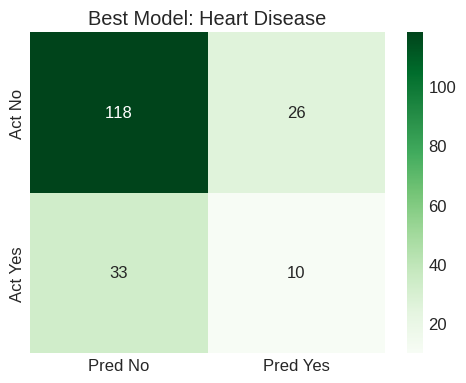

In [30]:

best_disease = disease_cols[np.argmax(f1_scores)]

best_cm = np.array([
    [results[best_disease]['TN'], results[best_disease]['FP']],
    [results[best_disease]['FN'], results[best_disease]['TP']]
])

plt.figure(figsize=(5, 4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Act No', 'Act Yes'])

plt.title(f'Best Model: {best_disease}')
plt.tight_layout()
plt.show()

## WORST CONFUSION MATRIX

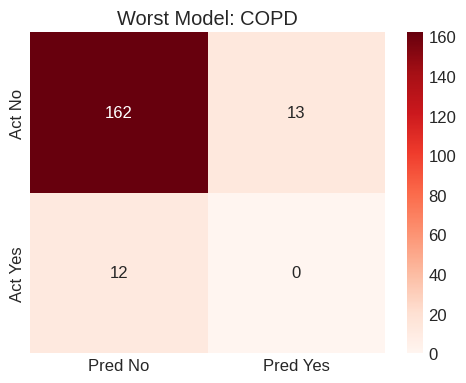

In [31]:
print("\n ")

worst_disease = disease_cols[np.argmin(f1_scores)]

worst_cm = np.array([
    [results[worst_disease]['TN'], results[worst_disease]['FP']],
    [results[worst_disease]['FN'], results[worst_disease]['TP']]
])

plt.figure(figsize=(5, 4))
sns.heatmap(worst_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Act No', 'Act Yes'])

plt.title(f'Worst Model: {worst_disease}')
plt.tight_layout()
plt.show()

## PRECISION-RECALL CURVES

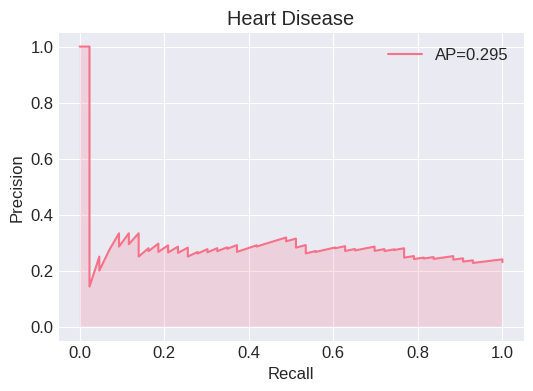

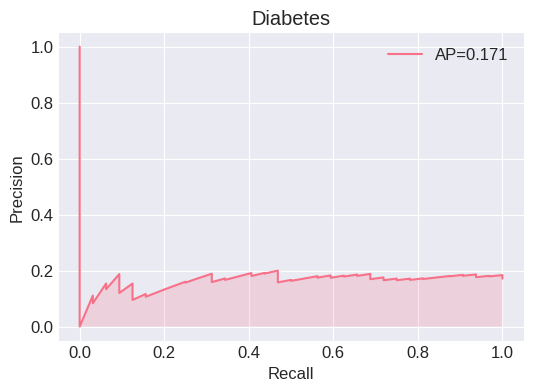

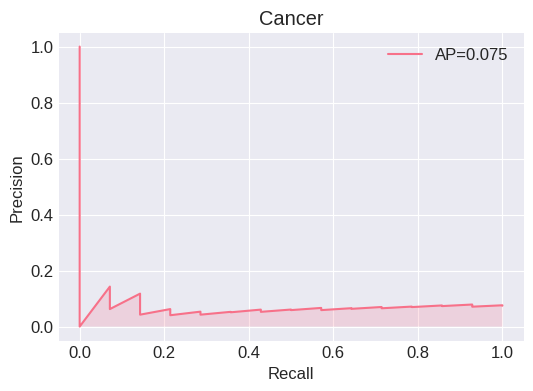

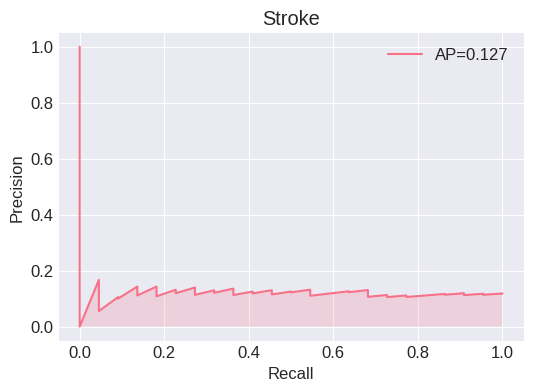

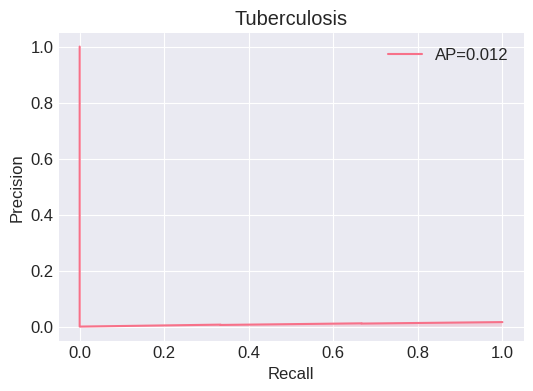

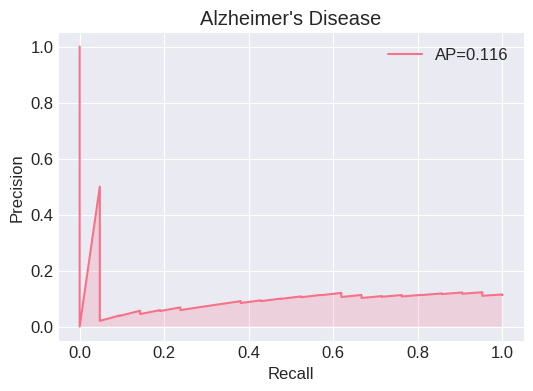

In [32]:


key_diseases = ['Heart Disease', 'Diabetes', 'Cancer', 'Stroke', 'Tuberculosis', "Alzheimer's Disease"]

for disease in key_diseases:
    if disease in disease_cols:
        idx = disease_cols.index(disease)

        precision, recall, _ = precision_recall_curve(y_test[disease], y_proba[:, idx])
        ap = average_precision_score(y_test[disease], y_proba[:, idx])

        plt.figure(figsize=(6, 4))
        plt.plot(recall, precision, label=f'AP={ap:.3f}')
        plt.fill_between(recall, precision, alpha=0.2)

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(disease)
        plt.legend()
        plt.grid(True)
        plt.show()

## ROC CURVES

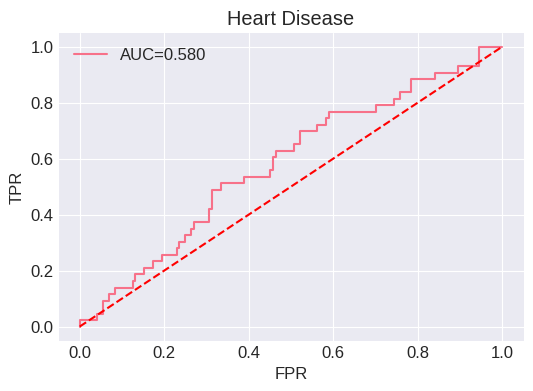

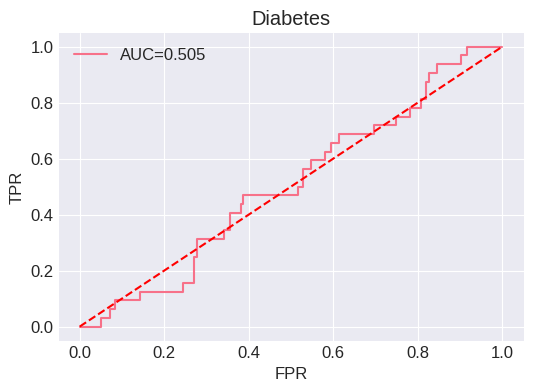

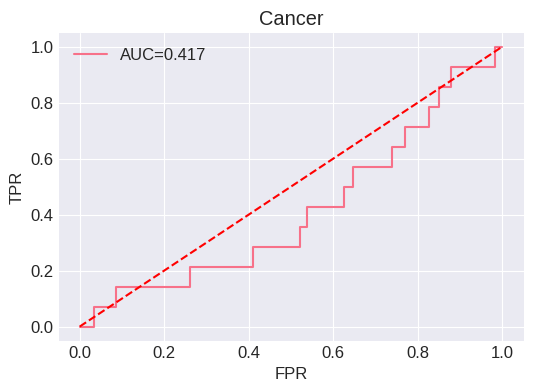

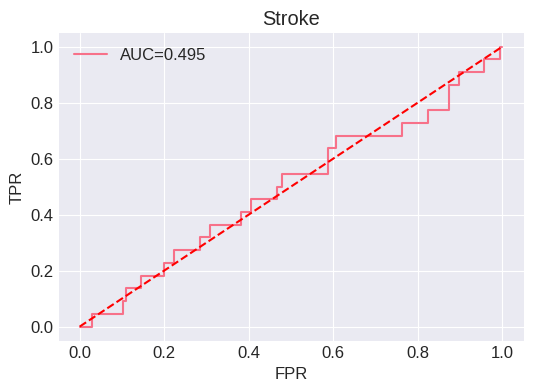

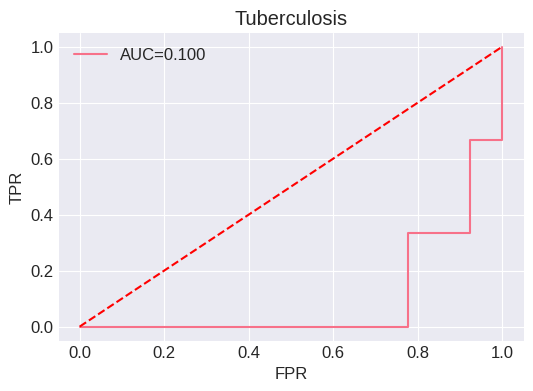

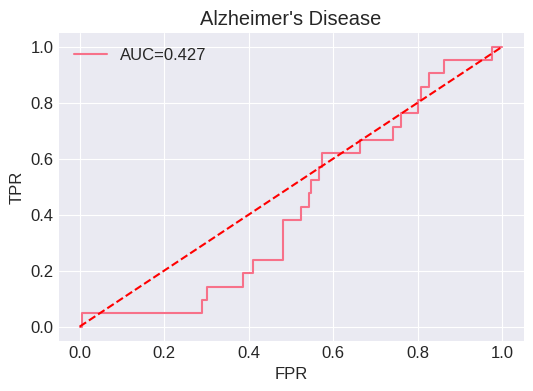

In [33]:


for disease in key_diseases:
    if disease in disease_cols:
        idx = disease_cols.index(disease)

        fpr, tpr, _ = roc_curve(y_test[disease], y_proba[:, idx])
        auc = roc_auc_score(y_test[disease], y_proba[:, idx])

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0, 1], [0, 1], 'r--')

        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(disease)
        plt.legend()
        plt.grid(True)
        plt.show()


Cardiovascular:
  F1: 0.1932
  Recall: 0.1845
  Precision: 0.2041

Metabolic:
  F1: 0.1327
  Recall: 0.1225
  Precision: 0.1456

Respiratory:
  F1: 0.0000
  Recall: 0.0000
  Precision: 0.0000

Neurological:
  F1: 0.0270
  Recall: 0.0238
  Precision: 0.0312

Cancer:
  F1: 0.5136
  Recall: 0.5126
  Precision: 0.5190

Liver:
  F1: 0.4704
  Recall: 0.4864
  Precision: 0.4688


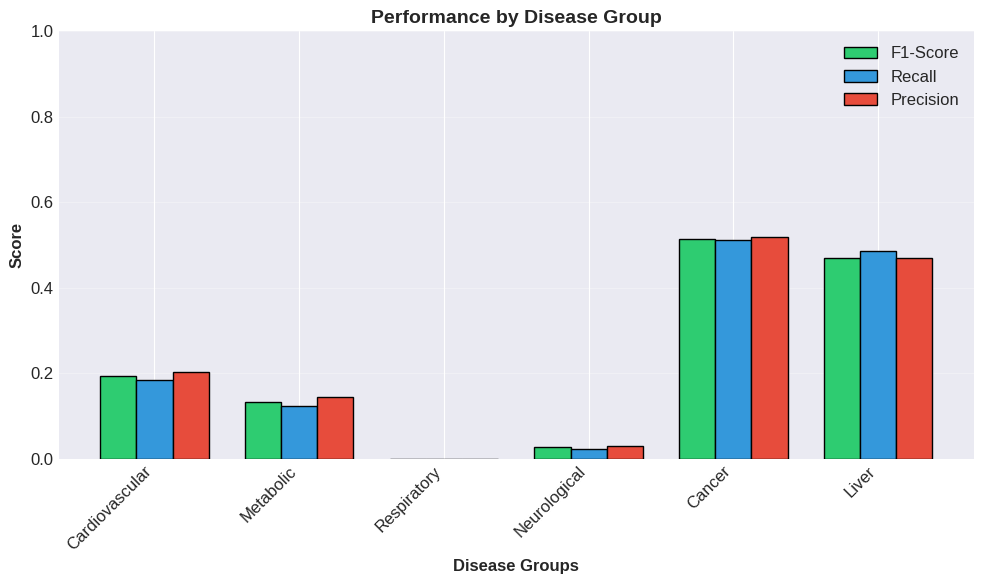

In [35]:


groups = {
    "Cardiovascular": ["Heart Disease", "Stroke"],
    "Metabolic": ["Diabetes", "Kidney Disease"],
    "Respiratory": ["COPD", "Tuberculosis"],
    "Neurological": ["Alzheimer's Disease", "Parkinson's Disease"],
    "Cancer": ["Cancer"],
    "Liver": ["Liver Disease"]
}

group_results = {}
for group, diseases in groups.items():
    indices = [disease_cols.index(d) for d in diseases]
    group_f1 = f1_score(y_test.iloc[:, indices], y_pred[:, indices], average='macro', zero_division=0)
    group_recall = recall_score(y_test.iloc[:, indices], y_pred[:, indices], average='macro', zero_division=0)
    group_precision = precision_score(y_test.iloc[:, indices], y_pred[:, indices], average='macro', zero_division=0)
    
    group_results[group] = {
        'F1': group_f1,
        'Recall': group_recall,
        'Precision': group_precision
    }
    print(f"\n{group}:")
    print(f"  F1: {group_f1:.4f}")
    print(f"  Recall: {group_recall:.4f}")
    print(f"  Precision: {group_precision:.4f}")

# Visualization: Group performance
fig, ax = plt.subplots(figsize=(10, 6))
groups_list = list(group_results.keys())
f1_scores_group = [group_results[g]['F1'] for g in groups_list]
recall_scores = [group_results[g]['Recall'] for g in groups_list]
precision_scores = [group_results[g]['Precision'] for g in groups_list]

x = np.arange(len(groups_list))
width = 0.25

ax.bar(x - width, f1_scores_group, width, label='F1-Score', color='#2ecc71', edgecolor='black')
ax.bar(x, recall_scores, width, label='Recall', color='#3498db', edgecolor='black')
ax.bar(x + width, precision_scores, width, label='Precision', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Disease Groups', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Performance by Disease Group', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(groups_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [36]:

print("\n MODEL PERFORMANCE SUMMARY")

print(f" Best Macro F1: {macro_f1:.4f}")
print(f" Best Micro F1: {micro_f1:.4f}")
print(f" Best Weighted F1: {weighted_f1:.4f}")


 MODEL PERFORMANCE SUMMARY
 Best Macro F1: 0.0844
 Best Micro F1: 0.1214
 Best Weighted F1: 0.1181
